    Final Report

    1. Business problem

Контекст та задача:

Проєкт спрямований на вирішення задачі багатокласової класифікації (Multiclass Classification) для телеком-оператора (Vodafone). Головна мета — спрогнозувати вікову категорію абонента на основі патернів його активності (кількість дзвінків, тривалість сесій, використання інтернету тощо).

Бізнес-цінність:

Розуміння вікової структури бази абонентів дозволяє компанії:

1. Пропонувати максимально релевантні тарифні плани.

2. Надавати персоналізовані послуги.

3. Ефективно таргетувати маркетингові кампанії.

Ціна помилки та керування ризиками (Ключовий фокус):

У цій бізнес-задачі ризики є асиметричними. Найбільш критичною помилкою є класифікація неповнолітнього користувача як дорослого (False Positive для дорослих класів). Це може призвести до показу віково обмеженої реклами (наприклад, алкоголь або азартні ігри) неповнолітнім.

Такі помилки створюють ризики для бренду та можуть викликати регуляторні або репутаційні проблеми. Тому ключовим завданням є не лише максимізація загальної точності (Accuracy), але й мінімізація критичних помилок, пов’язаних з неправильною ідентифікацією неповнолітніх користувачів.

    2. Data overview
   
Початковий датасет містив 210 000 записів та 1294 ознаки, 1275 з яких мали числовий формат (float64).

Виявлені виклики та рішення:

Клас-імбаланс: Вікові класи 4 та 5 сумарно складали близько 60% вибірки, тоді як клас 1 (діти) — менше 5%.

Оптимізація ресурсів (Stratified Sampling): Для пришвидшення ітерацій розробки початковий обсяг було зменшено до 105 000 рядків. 

Ключовий нюанс: застосовано сувору стратифікацію, що дозволило зберегти оригінальні пропорції дисбалансу класів, щоб моделі навчалися на реальному, а не спотвореному розподілі даних.

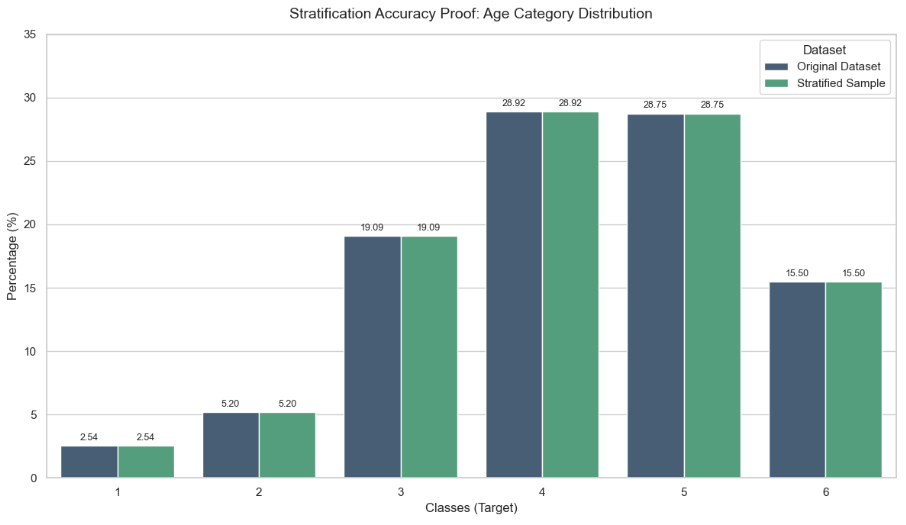

    3. Cleaning, Preprocessing & Feature Engineering
    
Природа пропусків у числових даних з точки зору телеком-бізнесу означала фізичну відсутність активності абонента. Тому всі NaN було заповнено нулями — ідеальний сценарій для алгоритмів на базі дерев рішень, які легко створюють спліти за умовою "більше/дорівнює нулю".

Ключові кроки підготовки даних:

1. Відфільтровано 13 константних і майже константних ознак, вилучено технічні ідентифікатори.

2. Для моделювання залишено 102 ознаки (плюс таргет), які мають чітко задукоментований опис.

3. Проведено агрегацію дублюючих фічей: використано загальні лічильники (gas_stations_sms, banks_sms_count), що зменшило розмірність та ризик мультиколінеарності.

4. Frequency Encoding для категорій: Для категоріальних ознак було застосовано Frequency Encoding (кодування частотою). Це дозволило перетворити категорії на числові значення, зберігши інформацію про їхню популярність, що є оптимальним форматом для роботи алгоритмів градієнтного бустингу.

5. Random Noise Benchmark: На етапі відбору ознак (Feature Selection) впроваджено контрольну фічу з випадковим шумом. Усі ознаки, чия прогностична сила виявилася нижчою за цей "шумовий бар'єр" (за метриками Mutual Information та Spearman), були видалені.

Після проведення всіх етапів, залишилось 90 ознак повністю придатних для навчання моделей.

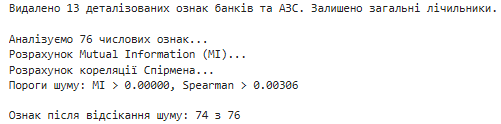

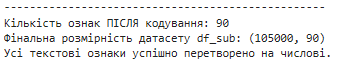

    4. EDA (інсайти)
    
Для пошуку складних нелінійних патернів використовувалися метрика Mutual Information та рангова кореляція Спірмена. Найбільший вплив на прогноз мають:

1. lifetime — тривалість перебування абонента в мережі є найсильнішим і найстабільнішим предиктором.

2. instagram_volume та intagram_count — трафік соцмереж працює як чіткий маркер для молодших груп.

3. DATA_VOLUME_WEEKDAYS / DATA_VOLUME_WEEKENDS — патерни споживання даних стабільно відрізняються залежно від віку.

4. CALCULATION_METHOD_ID — тип тарифу (контракт/передоплата) суттєво корелює з віком.

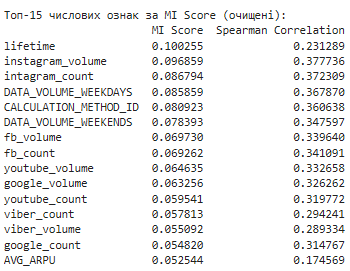

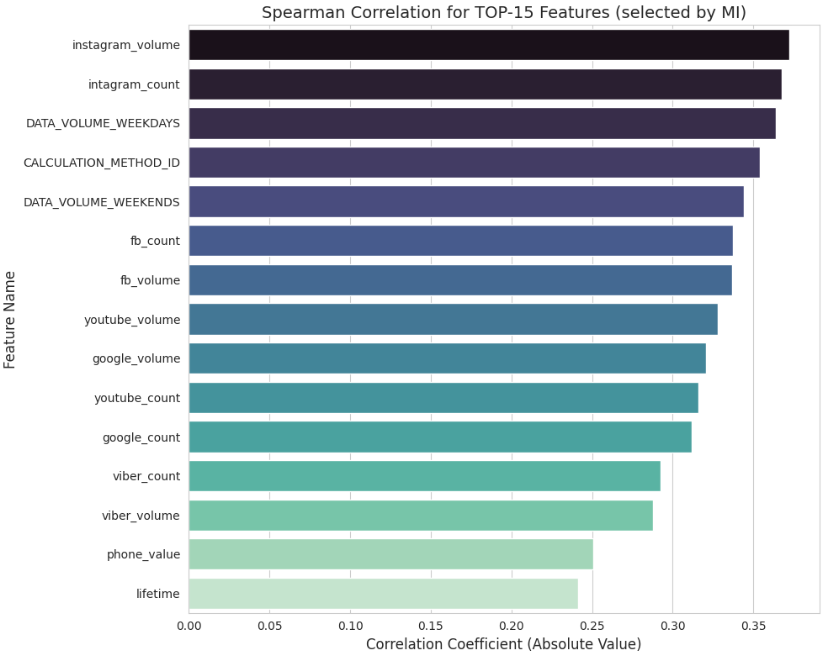

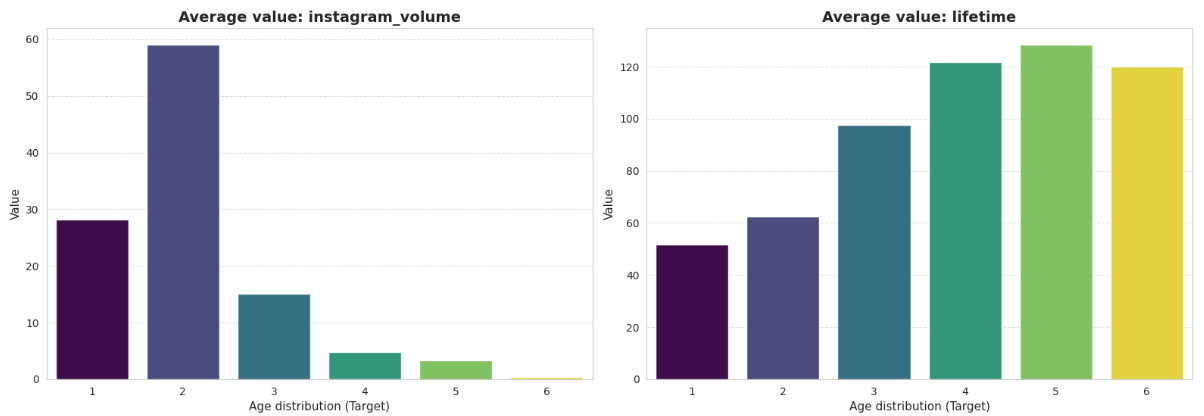

    5. Modeling
    
Ансамблеві моделі (Gradient Boosting) перевершили лінійні підходи за метрикою F1 (Логістична регресія — 40.8%, kNN — 35.46%). Базові бустинги одразу показали ~46%.

Технічний вибір:
Для фінальної оптимізації трійки лідерів (HistGradientBoosting, LightGBM, XGBoost) було свідомо обрано RandomizedSearchCV замість GridSearchCV. Зважаючи на обсяг даних (105к рядків) та кількість гіперпараметрів, цей метод забезпечив оптимальний баланс між обчислювальною ефективністю та глибиною пошуку найкращих параметрів (швидкість навчання, глибина дерев, регуляризація).

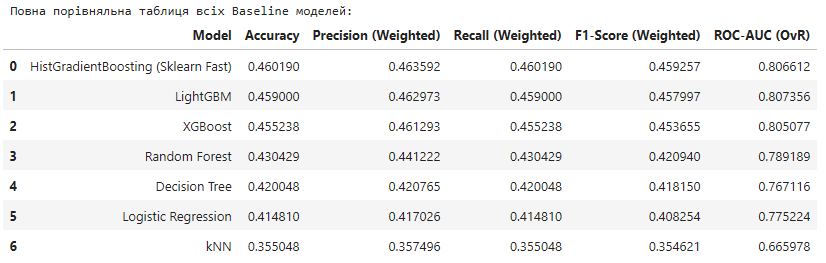

    6. Results & comparison
    
Результати валідації після тюнінгу:

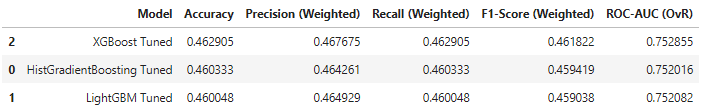

Фінальним переможцем обрано XGBoost (colsample_bytree: 0.8, learning_rate: 0.1, max_depth: 5, n_estimators: 200).

Нюанси оцінки якості:

1. Надійність метрик (F1-Score): Через дисбаланс класів Accuracy є оманливою. F1-Score на рівні ~0.46 доводить, що модель успішно класифікує міноритарні класи, а не просто "вгадує" більшість.

2. ROC-AUC (One-vs-Rest): Для багатокласової задачі застосовано макро-усереднення OvR ("один проти всіх"). Показник > 0.75 підтверджує чудову роздільну здатність моделі.

    7. Limitations & next steps
    
Обмеження:

Абсолютна точність у 46% (що втричі краще за випадкове вгадування у 16.6%) залишає простір для хибних прогнозів. Як зазначалося, сплутування дітей з дорослими є недопустимим.

Бізнес-стратегія (Next Steps):

Для вирішення проблеми Brand Safety застосовується Precision-Recall Trade-off. За допомогою стратегії Threshold Tuning (встановлення жорсткого порогу впевненості моделі, наприклад, 0.66), класифікатор перетворюється на прецизійний фільтр. Ми свідомо жертвуємо повнотою (Recall) заради 100% точності (Precision).

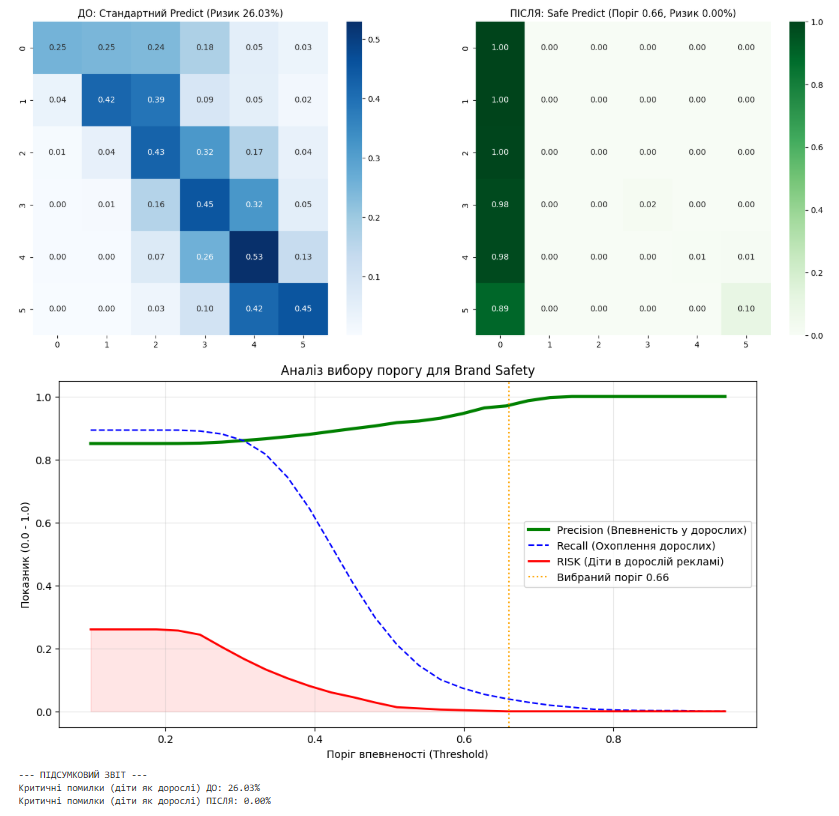

Це створює два бізнес-сегменти:

Преміум-сегмент "High-Confidence" (~10% аудиторії): Гарантовані дорослі. Юридичні ризики дорівнюють нулю — сюди таргетується агресивна реклама 18+.

"Безпечна зона" (General Audience): Абоненти, щодо яких модель має сумнів. Вони залишаються монетизованими через показ реклами товарів масового споживання (без вікових обмежень).

Підсумок: Розроблене рішення надає компанії Vodafone гнучкий інструмент для управління ризиками та безпечної монетизації трафіку.

    Що можна покращити (Future Work & Next Steps):

Для подальшого підвищення базової точності моделі (щоб розширити преміум-сегмент без втрати безпеки) пропонуються такі технічні кроки:

Просунутий Feature Engineering: Поглиблення роботи з даними через створення складніших комбінованих ознак. Наприклад, конструювання нових змінних на основі співвідношень (ratio) різних типів трафіку, взаємодії між категоріями додатків або глибшого аналізу часових патернів активності (різниця поведінки вдень/вночі чи у вихідні/будні), що дозволить моделі краще розрізняти суміжні вікові групи.

Ансамблювання (Stacking): Створення мета-моделі, яка б об'єднала прогнози трьох наших лідерів (XGBoost, LightGBM, HistGradientBoosting) для досягнення ще вищої стабільності та математичної точності класифікації.